# Projet Challenge: Application Web Interactive de Prédiction du Cancer du Sein

## Contexte du Projet
Développement d'une application web de machine learning pour la classification 
des tumeurs du sein en bénignes ou malignes basée sur des caractéristiques cellulaires.

## Objectifs Pédagogiques
• Développer une mini-application web de ML avec interface interactive

• Automatiser le téléchargement et traitement des données

• Expérimenter plusieurs modèles de classification

• Visualiser automatiquement résultats, métriques et courbes ROC

• Intégrer une API d'interprétation de modèles

• Présenter une solution fonctionnelle et intuitive

Auteur: Ikram Khemiri

Date: 17/10/2025

## PARTIE 1: IMPORT DES LIBRAIRIES

In [454]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Configuration pour des visualisations professionnelles
sns.set_style("whitegrid")
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## PARTIE 2: CHARGEMENT ET EXPLORATION

In [455]:
df = pd.read_csv("data.csv")

 1. Premières lignes


In [456]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


2. Dimensions


In [457]:
print(f"\n2. Dimensions: {df.shape[0]} patients, {df.shape[1]} caractéristiques")


2. Dimensions: 569 patients, 32 caractéristiques


 3. Types de données


In [458]:
print(df.dtypes)

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

 4. Informations détaillées

In [459]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## PARTIE 3: ANALYSE STATISTIQUE

1. Description statistique descriptive

In [460]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

2. Analyse de la variable cible

In [461]:
print("Distribution originale de 'diagnosis':")
original_counts = df['diagnosis'].value_counts()
print(original_counts)

Distribution originale de 'diagnosis':
diagnosis
B    357
M    212
Name: count, dtype: int64


In [462]:
df['diagnosis'].dtype

dtype('O')

In [463]:
df.diagnosis.unique()

array(['M', 'B'], dtype=object)

M-> Malignint et  B-> Benign

In [464]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [465]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

(array([0, 1]), [Text(0, 0, 'B'), Text(1, 0, 'M')])

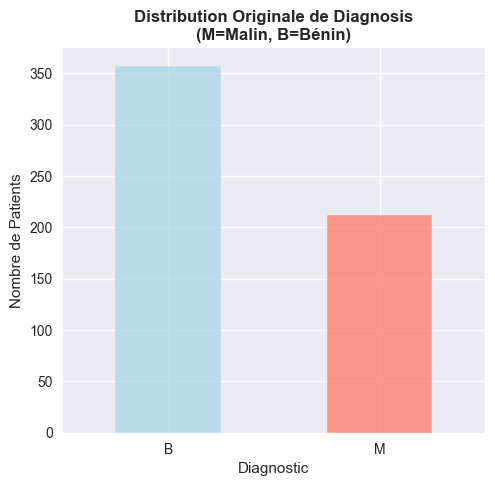

In [466]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
original_counts.plot(kind='bar', color=['lightblue', 'salmon'], alpha=0.8)
plt.title('Distribution Originale de Diagnosis\n(M=Malin, B=Bénin)', fontweight='bold')
plt.xlabel('Diagnostic')
plt.ylabel('Nombre de Patients')
plt.xticks(rotation=0)

INTERPRÉTATION AVANT CONVERSION:

• M (Malin): Tumeurs cancéreuses - nécessitent un traitement

• B (Bénin): Tumeurs non-cancéreuses - surveillance généralement suffisante

• Distribution: Environ 63% bénignes, 37% malignes

3. Analyse des valeurs manquantes:

In [467]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

<Axes: >

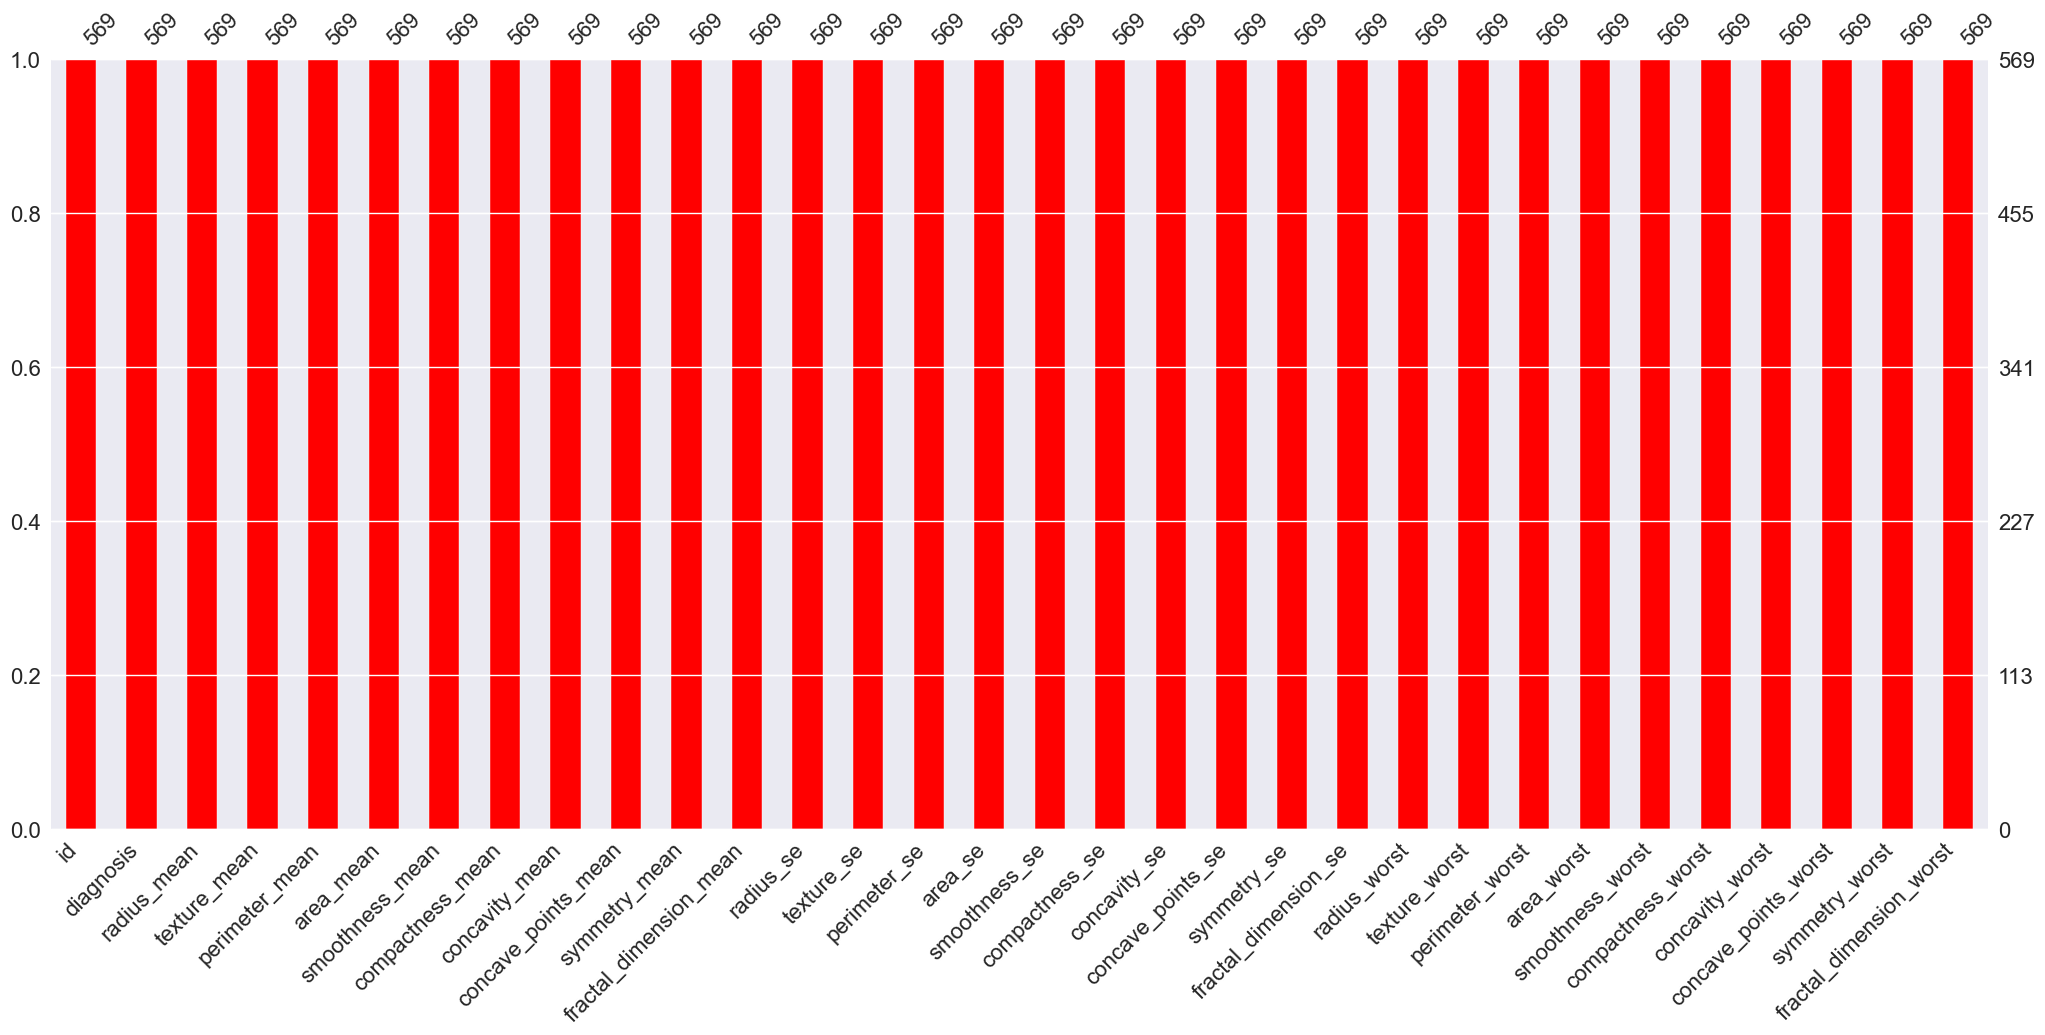

In [468]:
msno.bar(df, color="red")

Aucune valeur manquante détectée

4. Conversion de la Variable Cible

In [469]:
df['diagnosis'] = df['diagnosis'].apply(lambda val:1 if val=='M' else 0)

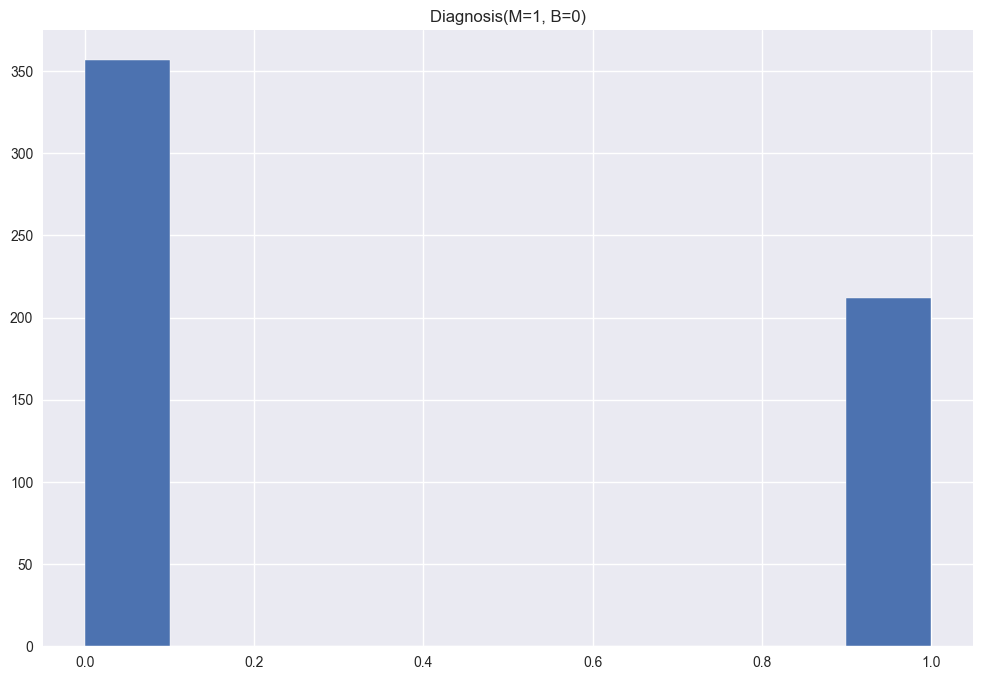

In [470]:
plt.hist(df['diagnosis'])
plt.title('Diagnosis(M=1, B=0)')
plt.show()

5. Analyse Statistique par Type de Diagnostic

Comparaison des statistiques par diagnostic:

🔹 Radius Mean:
   Bénin (0):  mean=12.15, std=1.78
   Malin (1):  mean=17.46, std=3.20
   Différence: 5.32

🔹 Texture Mean:
   Bénin (0):  mean=17.91, std=4.00
   Malin (1):  mean=21.60, std=3.78
   Différence: 3.69

🔹 Perimeter Mean:
   Bénin (0):  mean=78.08, std=11.81
   Malin (1):  mean=115.37, std=21.85
   Différence: 37.29

🔹 Area Mean:
   Bénin (0):  mean=462.79, std=134.29
   Malin (1):  mean=978.38, std=367.94
   Différence: 515.59


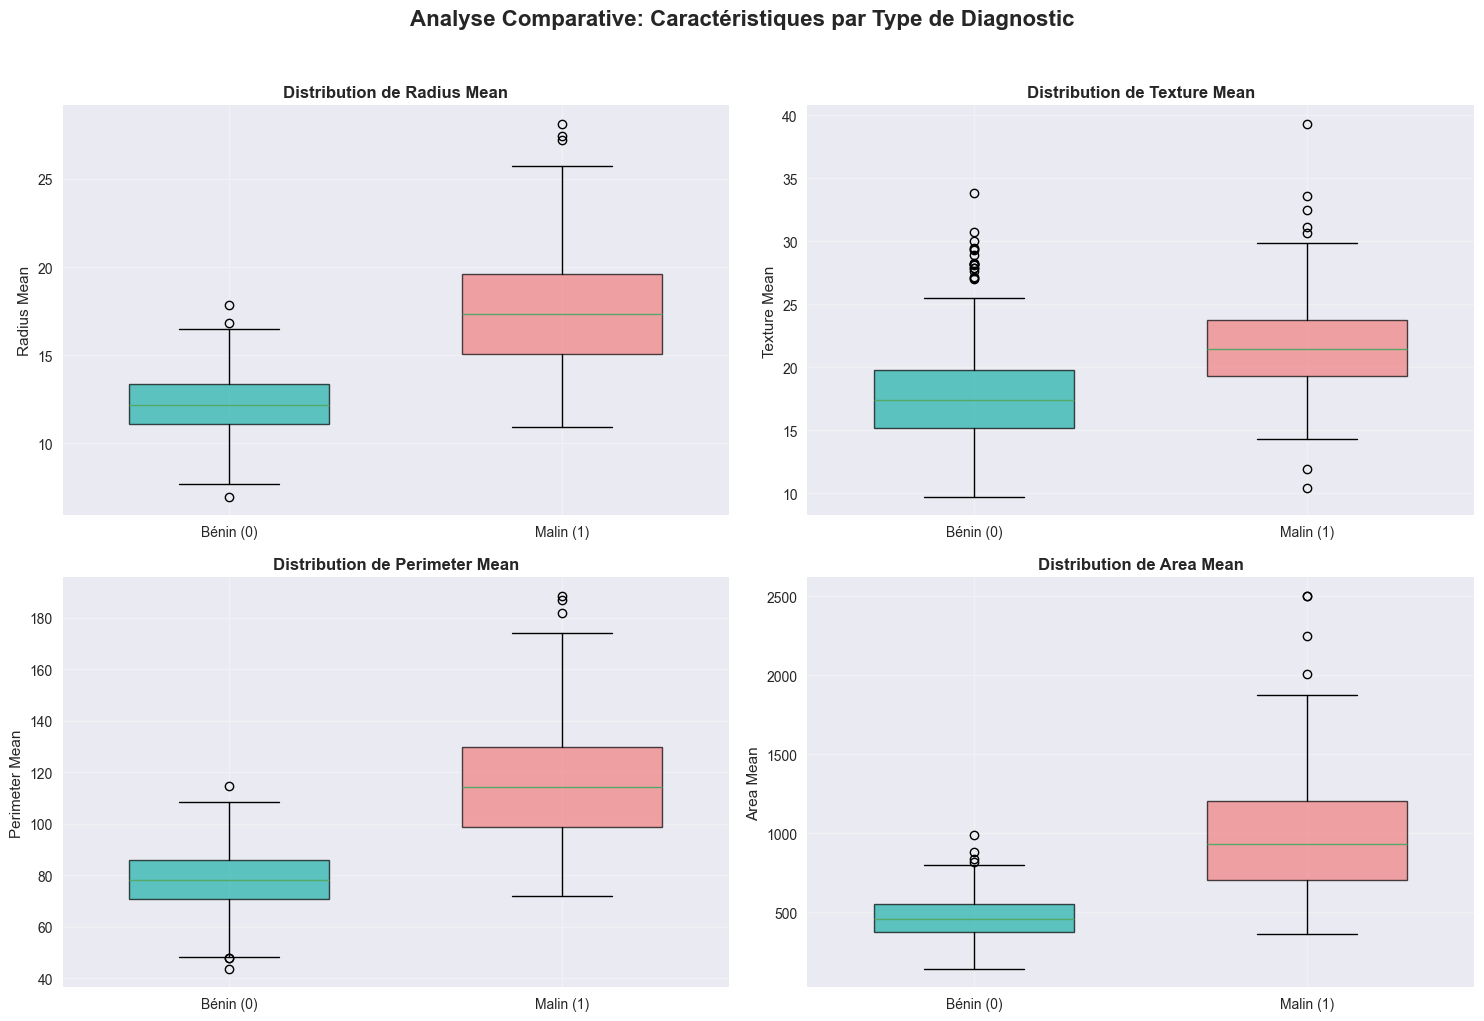

In [471]:
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']

print("Comparaison des statistiques par diagnostic:")
for feature in key_features:
    print(f"\n🔹 {feature.replace('_', ' ').title()}:")
    
    stats_benign = df[df['diagnosis'] == 0][feature].describe()
    stats_malignant = df[df['diagnosis'] == 1][feature].describe()
    
    print(f"   Bénin (0):  mean={stats_benign['mean']:.2f}, std={stats_benign['std']:.2f}")
    print(f"   Malin (1):  mean={stats_malignant['mean']:.2f}, std={stats_malignant['std']:.2f}")
    print(f"   Différence: {stats_malignant['mean'] - stats_benign['mean']:.2f}")

plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    
    data_to_plot = [df[df['diagnosis'] == 0][feature], 
                    df[df['diagnosis'] == 1][feature]]
    
    box = plt.boxplot(data_to_plot, labels=['Bénin (0)', 'Malin (1)'], 
                     patch_artist=True, widths=0.6)
    
    colors = ['lightseagreen', 'lightcoral']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    plt.title(f'Distribution de {feature.replace("_", " ").title()}', fontweight='bold')
    plt.ylabel(feature.replace('_', ' ').title())
    plt.grid(True, alpha=0.3)

plt.suptitle('Analyse Comparative: Caractéristiques par Type de Diagnostic', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## PARTIE 4: ANALYSE EXPLORATOIRE DES DONNÉES

1. Distribution des Variables

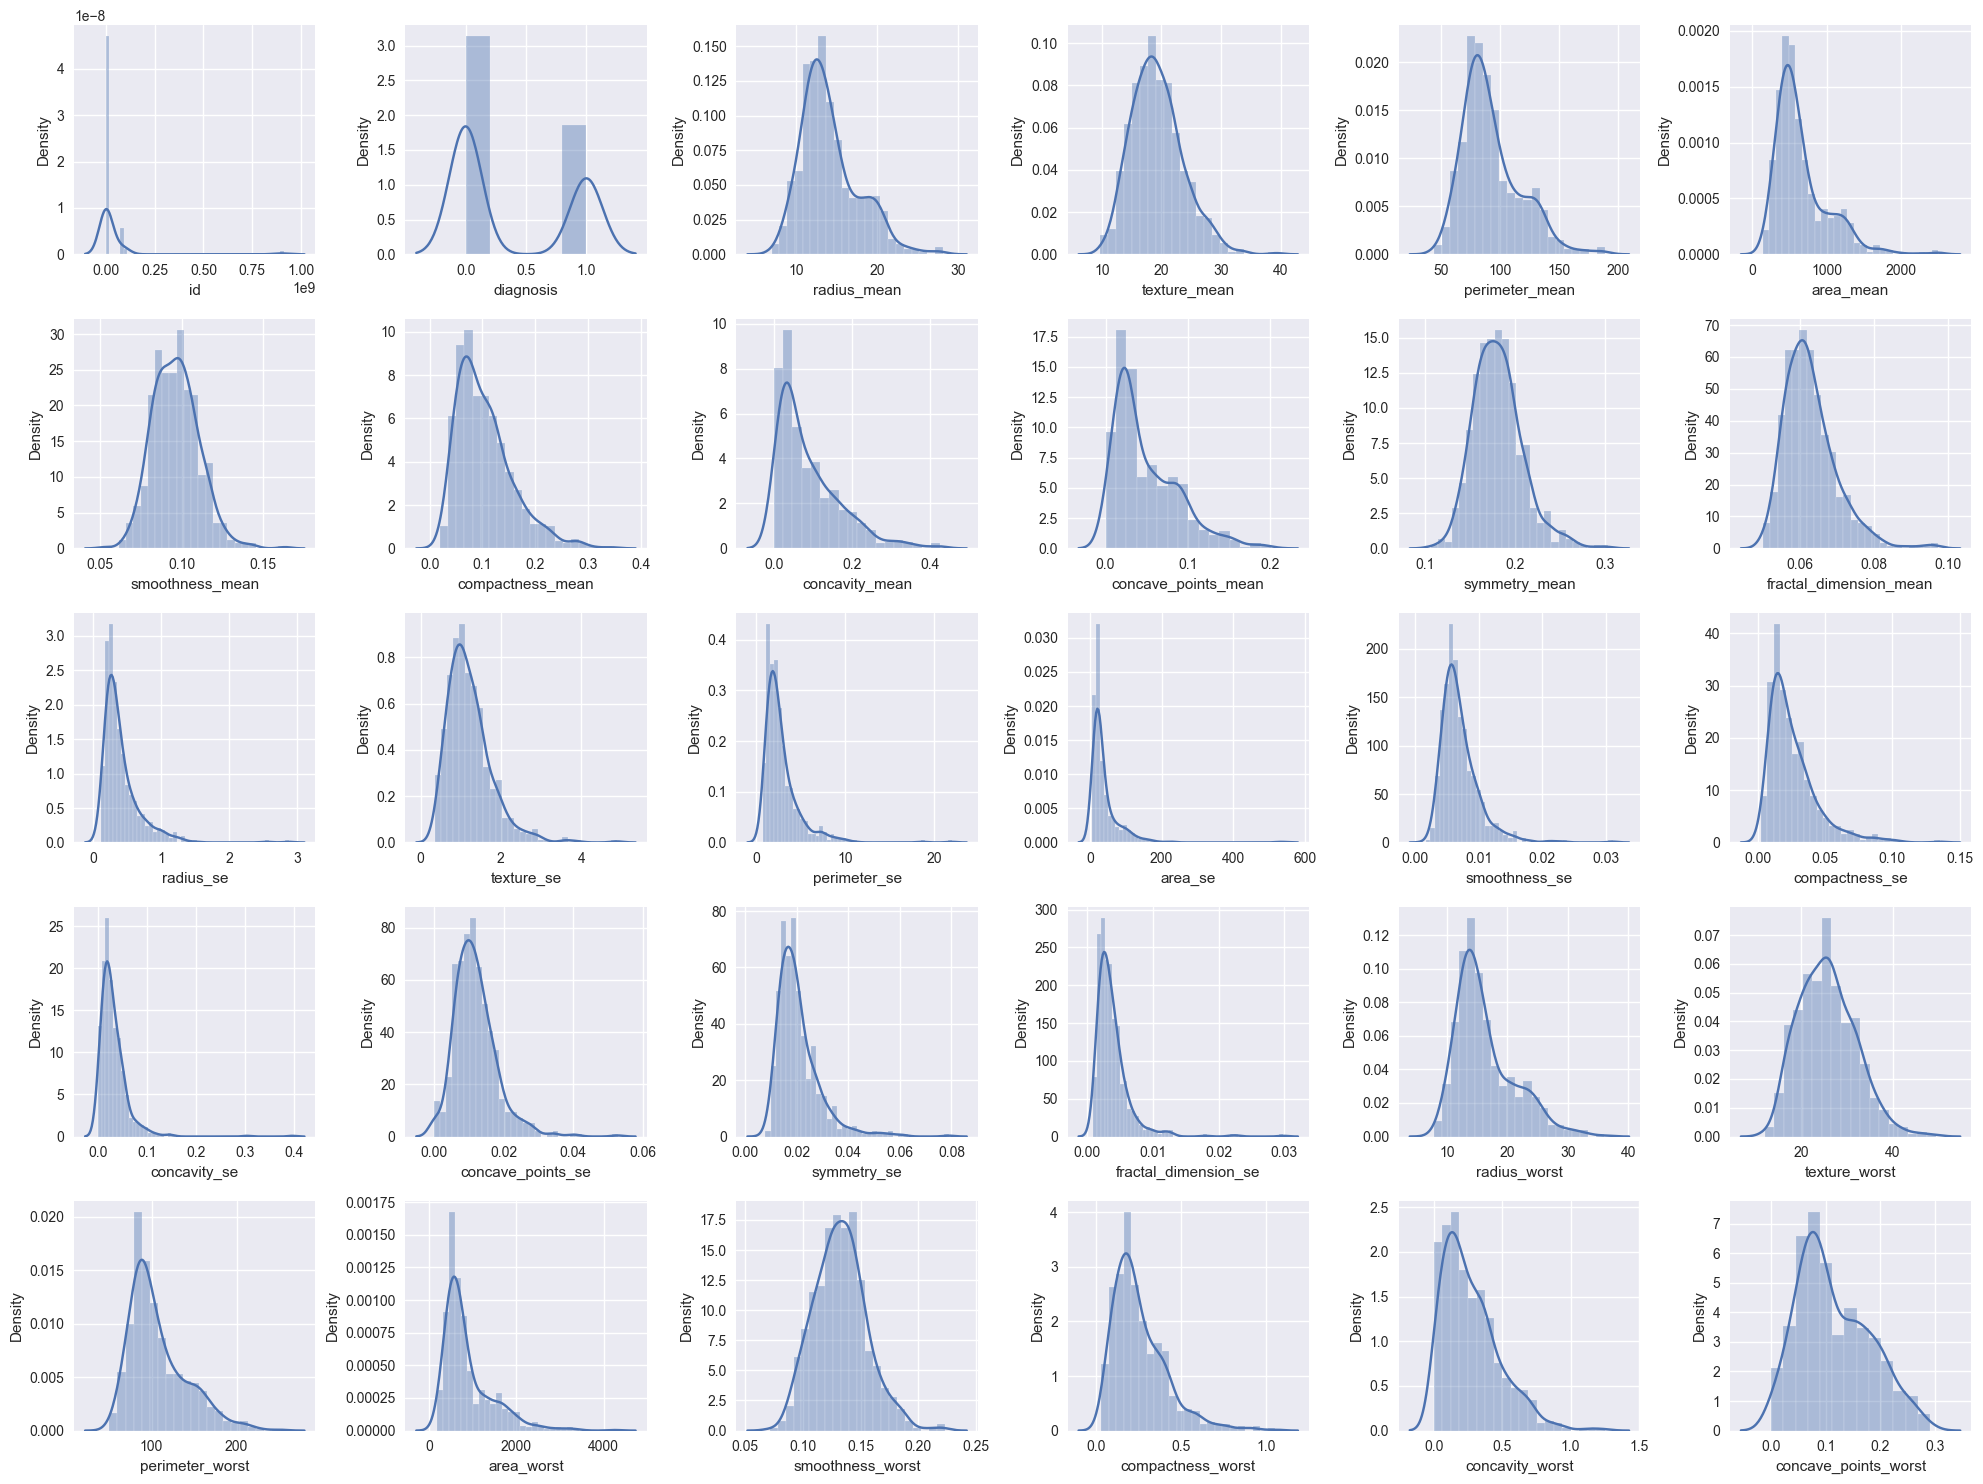

In [472]:
plt.figure(figsize=(20,15))
plotnumber=1
for column in df:
    if plotnumber<=30:
        ax = plt.subplot(5,6, plotnumber)
        sns.distplot(df[column])
        plt.xlabel(column)
    plotnumber+=1

plt.tight_layout()
plt.show()

2.ANALYSE APPROFONDIE DES CORRÉLATIONS

In [473]:
df.corr()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
id,1.000000,0.039769,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,...,0.082405,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866
diagnosis,0.039769,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.074626,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.099770,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.073159,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.096893,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.012968,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.000096,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.050080,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave_points_mean,0.044158,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661


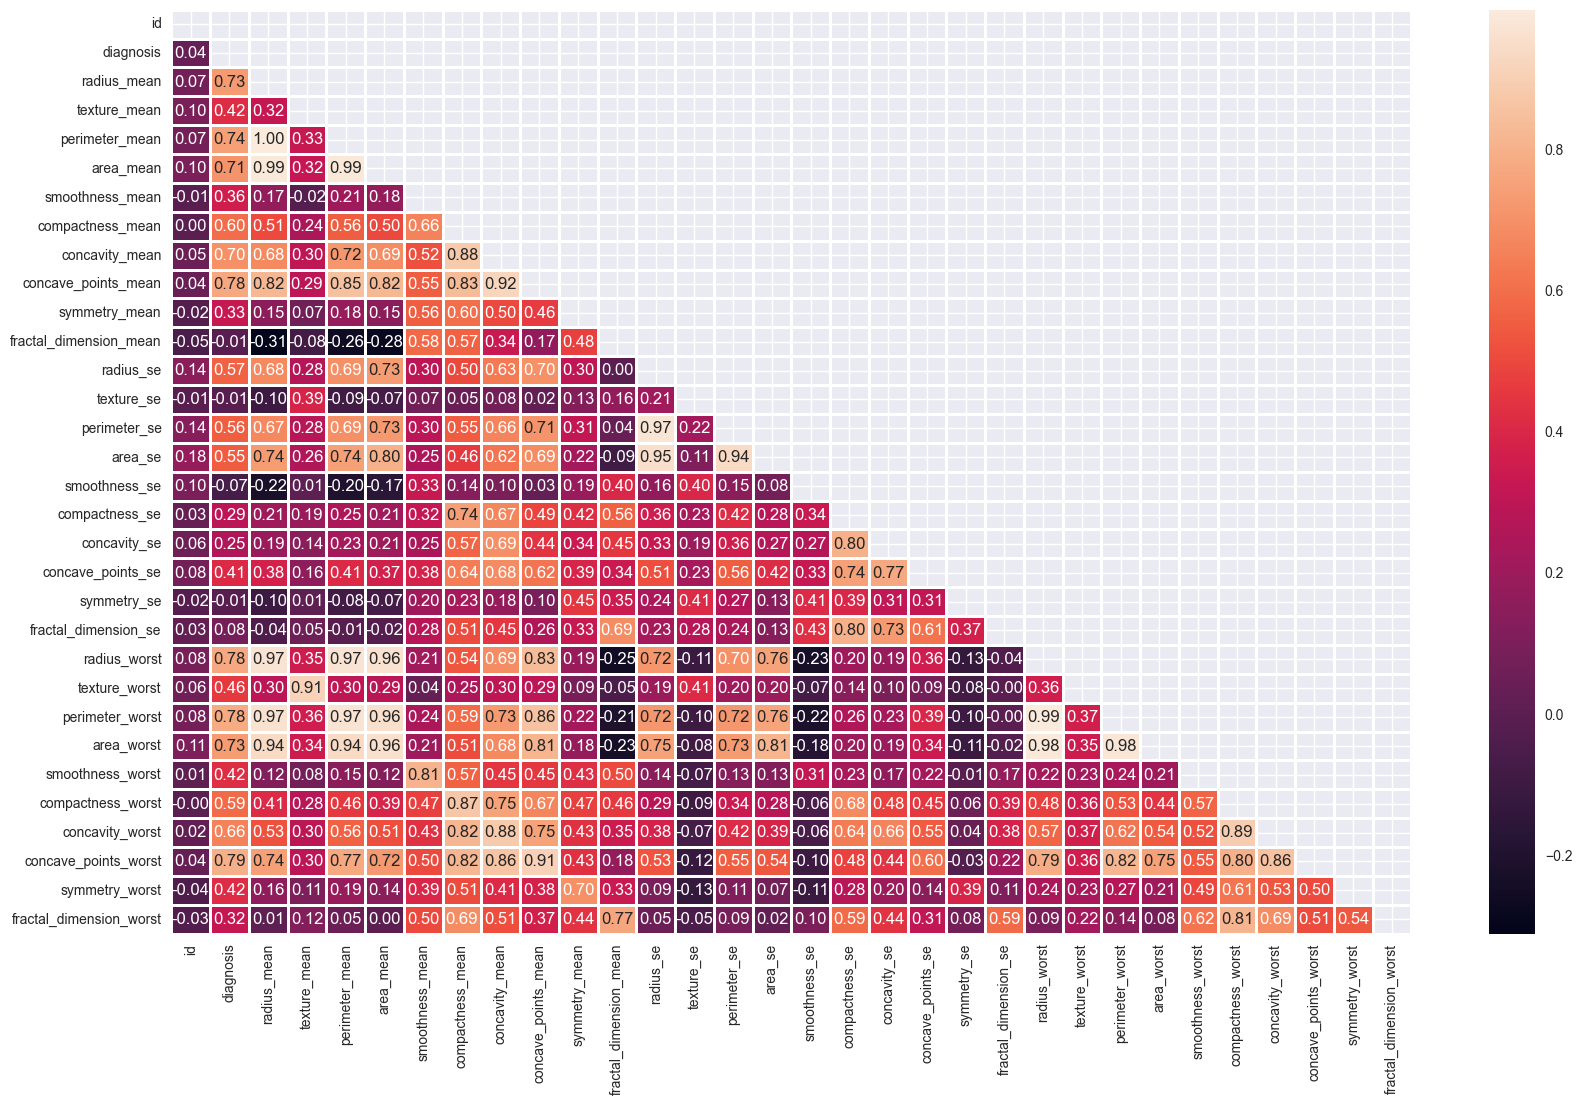

In [474]:

plt.figure(figsize=(20,12))
corr=df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, linewidths=1, annot=True, fmt = ".2f")
plt.show()

• FORTES corrélations positives (>0.9) entre: radius, perimeter, area

• Ces variables mesurent essentiellement la même chose (la taille)

• Problème de MULTICOLINÉARITÉ détecté

3. Analyse des Relations entre Variables

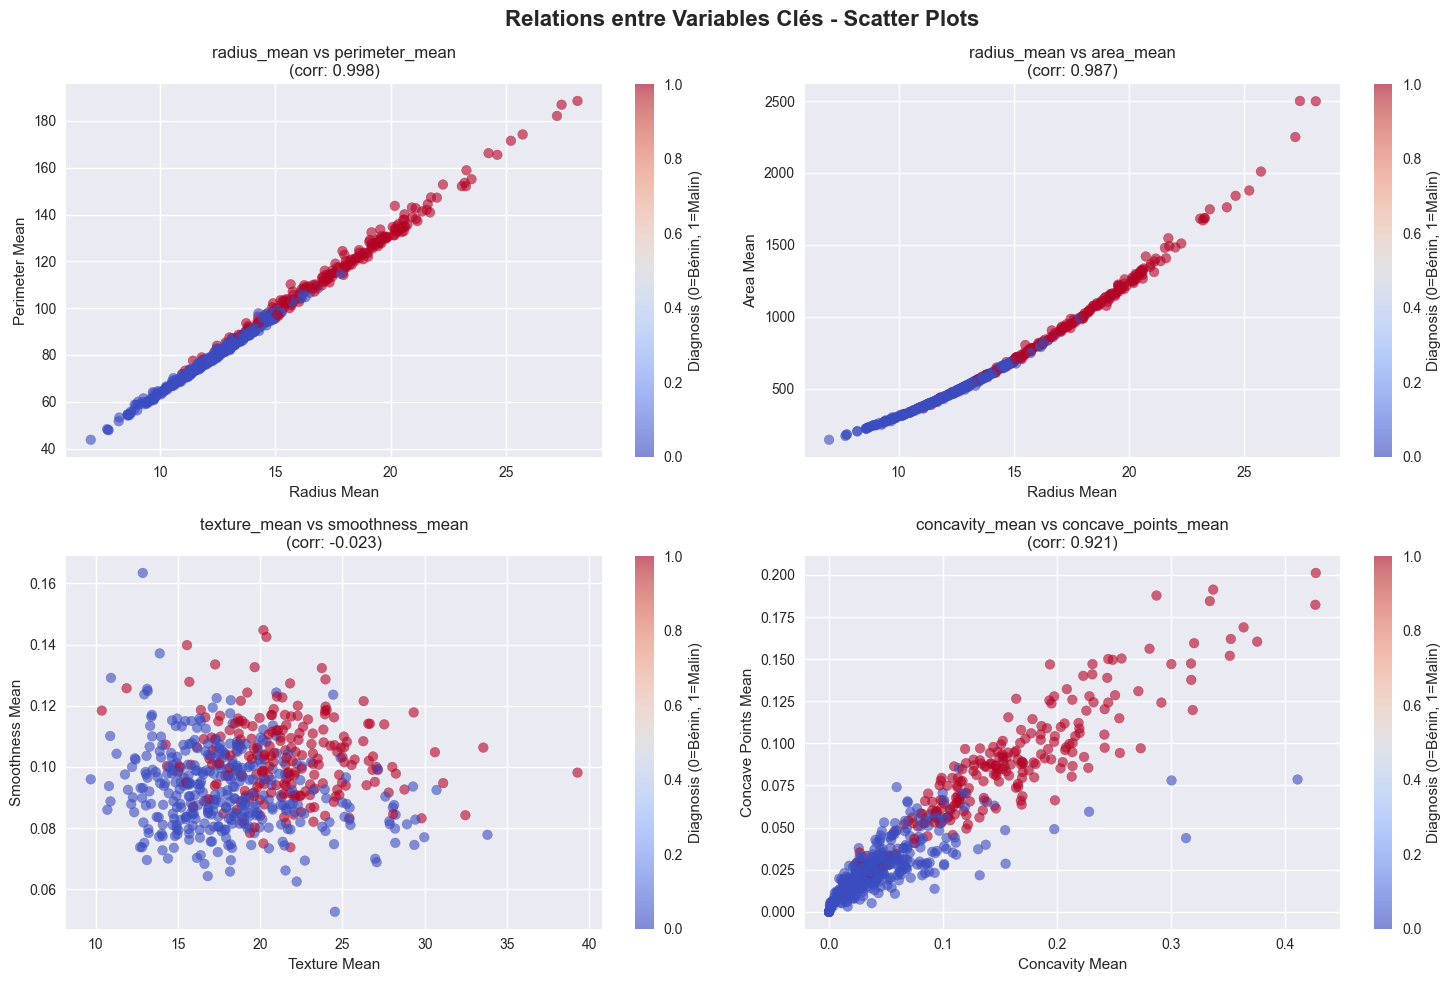

In [475]:
key_pairs = [
    ('radius_mean', 'perimeter_mean'),
    ('radius_mean', 'area_mean'), 
    ('texture_mean', 'smoothness_mean'),
    ('concavity_mean', 'concave_points_mean')
]

plt.figure(figsize=(15, 10))
for i, (var1, var2) in enumerate(key_pairs):
    plt.subplot(2, 2, i+1)
    
    scatter = plt.scatter(df[var1], df[var2], c=df['diagnosis'], 
                         cmap='coolwarm', alpha=0.6)
    plt.xlabel(var1.replace('_', ' ').title())
    plt.ylabel(var2.replace('_', ' ').title())
    plt.title(f'{var1} vs {var2}\n(corr: {df[var1].corr(df[var2]):.3f})')
    plt.colorbar(scatter, label='Diagnosis (0=Bénin, 1=Malin)')
    
plt.suptitle('Relations entre Variables Clés - Scatter Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

4. Analyse par Groupes 

In [476]:
discriminant_features = ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst']

print("Moyennes par type de diagnostic:")
for feature in discriminant_features:
    mean_benign = df[df['diagnosis'] == 0][feature].mean()
    mean_malignant = df[df['diagnosis'] == 1][feature].mean()
    
    print(f"• {feature}:")
    print(f"  - Bénin: {mean_benign:.2f}")
    print(f"  - Malin: {mean_malignant:.2f}") 
    print(f"  - Différence: {mean_malignant - mean_benign:.2f} (+{(mean_malignant/mean_benign - 1)*100:.1f}%)")

Moyennes par type de diagnostic:
• radius_worst:
  - Bénin: 13.38
  - Malin: 21.13
  - Différence: 7.76 (+58.0%)
• texture_worst:
  - Bénin: 23.52
  - Malin: 29.32
  - Différence: 5.80 (+24.7%)
• perimeter_worst:
  - Bénin: 87.01
  - Malin: 141.37
  - Différence: 54.36 (+62.5%)
• area_worst:
  - Bénin: 558.90
  - Malin: 1422.29
  - Différence: 863.39 (+154.5%)


5. Analyse des Segments de Patients

Table de contingence: Taille vs Diagnostic:
diagnosis        0    1
size_category          
Petit          165    6
Moyen          192  114
Grand            0   92


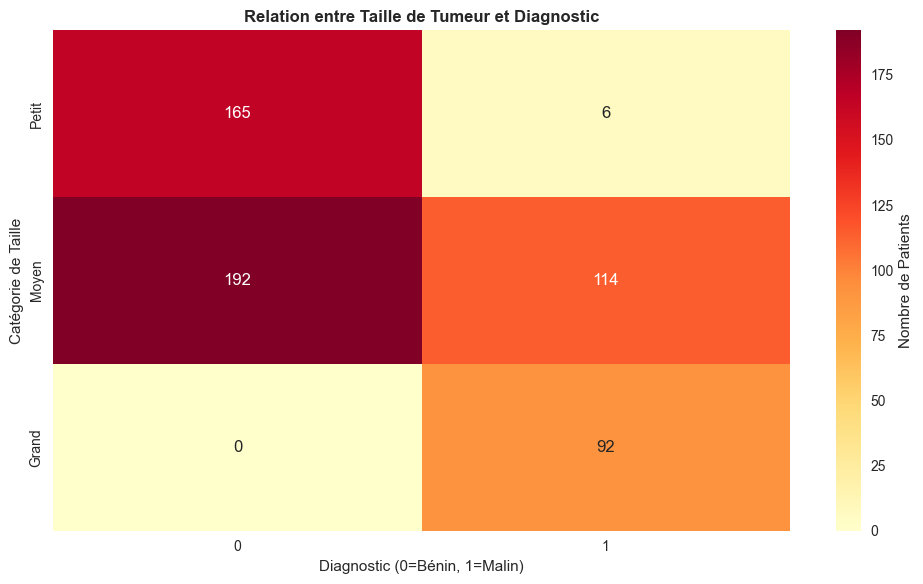

In [477]:
df['size_category'] = pd.cut(df['radius_mean'], 
                            bins=[0, 12, 18, 30], 
                            labels=['Petit', 'Moyen', 'Grand'])

df['texture_category'] = pd.cut(df['texture_mean'],
                               bins=[0, 15, 20, 30, 40],
                               labels=['Lisse', 'Normal', 'Rugueux', 'Très rugueux'])

contingency_table = pd.crosstab(df['size_category'], df['diagnosis'])
print("Table de contingence: Taille vs Diagnostic:")
print(contingency_table)

plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', 
            cbar_kws={'label': 'Nombre de Patients'})
plt.title('Relation entre Taille de Tumeur et Diagnostic', fontweight='bold')
plt.xlabel('Diagnostic (0=Bénin, 1=Malin)')
plt.ylabel('Catégorie de Taille')
plt.tight_layout()
plt.show()

## PARTIE 5: PRÉPARATION DES DONNÉES

1. Feature Selection

supprimer la colonne id elle est non pertinente dans notre cas : 

In [478]:
df.drop('id', axis=1, inplace=True)

In [479]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr().abs()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_df = corr_matrix.mask(mask)

to_drop = [x for x in tri_df.columns if (tri_df[x] > 0.92).any()]

df = df.drop(columns=to_drop, axis=1)

print("Dropped columns:", to_drop)
print("Nombre de colonnes restantes:", df.shape[1])

Dropped columns:

 ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst']
Nombre de colonnes restantes: 25


In [480]:
df.head()

,diagnosis,texture_mean,smoothness_mean,compactness_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,smoothness_se,...,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,size_category,texture_category
0,1,10.38,0.11840,0.27760,0.14710,0.2419,0.07871,0.9053,153.40,0.006399,...,17.33,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Moyen,Lisse
1,1,17.77,0.08474,0.07864,0.07017,0.1812,0.05667,0.7339,74.08,0.005225,...,23.41,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Grand,Normal
2,1,21.25,0.10960,0.15990,0.12790,0.2069,0.05999,0.7869,94.03,0.006150,...,25.53,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Grand,Rugueux
3,1,20.38,0.14250,0.28390,0.10520,0.2597,0.09744,1.1560,27.23,0.009110,...,26.50,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Petit,Rugueux
4,1,14.34,0.10030,0.13280,0.10430,0.1809,0.05883,0.7813,94.44,0.011490,...,16.67,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Grand,Lisse


32 feature reduce it 25 now

2. Division des Données en Ensembles d'Entraînement et de Test

In [481]:
X=df.drop('diagnosis', axis=1)
y=df['diagnosis']

In [482]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train ,y_test =train_test_split(X,y, test_size=0.2, random_state=0)

3. Standardisation des Variables Numériques

In [483]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# Fit scaler only on numeric columns of X_train and transform those same columns in X_train and X_test.
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [484]:
X_train.shape

(455, 24)

## PARTIE 6: MODÉLISATION ET OPTIMISATION

1.  Modèle 1: Régression Logistique

In [485]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns

if len(cat_cols) > 0:
    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
    X_train_enc, X_test_enc = X_train, X_test

log_reg.set_params(max_iter=1000)
log_reg.fit(X_train_enc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [486]:
y_pred = log_reg.predict(X_test_enc)

In [487]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0])

In [488]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_train, log_reg.predict(X_train_enc)))
log_reg_acc = accuracy_score(y_test, log_reg.predict(X_test_enc))
print(log_reg_acc)
y_pred = log_reg.predict(X_test_enc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.989010989010989
0.9649122807017544
[[66  1]
 [ 3 44]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        67
           1       0.98      0.94      0.96        47

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



2. Modèle 2: K-Nearest Neighbors

In [489]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [490]:
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns

if len(cat_cols) > 0:
    X_train_knn = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_knn = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_knn = X_test_knn.reindex(columns=X_train_knn.columns, fill_value=0)
else:
    X_train_knn, X_test_knn = X_train.copy(), X_test.copy()

scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn = KNeighborsClassifier()
knn.fit(X_train_knn_scaled, y_train)
y_pred = knn.predict(X_test_knn_scaled)

In [491]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0])

In [492]:
print(accuracy_score(y_train, knn.predict(X_train_knn_scaled)))
knn_acc = accuracy_score(y_test, knn.predict(X_test_knn_scaled))
print(knn_acc)
y_pred = knn.predict(X_test_knn_scaled)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9582417582417583
0.9473684210526315
[[67  0]
 [ 6 41]]
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        67
           1       1.00      0.87      0.93        47

    accuracy                           0.95       114
   macro avg       0.96      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



3.  Modèle 3: Support Vector Classifier (Optimisé)

In [493]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()

svc = SVC(probability=True)

parameters = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C': [0.01, 0.05, 0.1, 0.5, 1, 10, 15, 20]
}

grid_search = GridSearchCV(svc, parameters, cv=5, n_jobs=-1, verbose=1)
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()

svc = SVC(probability=True)

parameters = {
    'gamma': [0.0001, 0.001, 0.01, 0.1],
    'C': [0.01, 0.05, 0.1, 0.5, 1, 10, 15, 20]
}

rand_search = RandomizedSearchCV(svc, param_distributions=parameters, 
                                 n_iter=12, cv=5, n_jobs=-1, verbose=1, random_state=0)

grid_search = rand_search
grid_search.fit(X_train_enc, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,SVC(probability=True)
,param_distributions,"{'C': [0.01, 0.05, ...], 'gamma': [0.0001, 0.001, ...]}"
,n_iter,12
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [494]:
grid_search.best_params_

{'gamma': 0.01, 'C': 10}

In [495]:
grid_search.best_score_

np.float64(0.9802197802197803)

In [496]:
svc = SVC(C=15, gamma=0.01, probability=True)
svc = SVC(C=15, gamma=0.01, probability=True)
svc.fit(X_train_enc, y_train)

,C,15
,kernel,'rbf'
,degree,3
,gamma,0.01
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [497]:
y_pred = svc.predict(X_test_enc)

In [498]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0])

In [499]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Use the encoded/one-hot-encoded datasets that were used for fitting the SVC
print(accuracy_score(y_train, svc.predict(X_train_enc)))
svc_acc = accuracy_score(y_test, svc.predict(X_test_enc))
print(svc_acc)
y_pred = svc.predict(X_test_enc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9868131868131869
0.9824561403508771
[[67  0]
 [ 2 45]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        67
           1       1.00      0.96      0.98        47

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



4.  Modèle 4: Arbre de Décision (Optimisé)

In [500]:
from sklearn.tree import DecisionTreeClassifier

cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()

dtc = DecisionTreeClassifier()

parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 32, 1),
    'min_samples_leaf': range(1, 10, 1),
    'min_samples_split': range(2, 10, 1),
    'splitter': ['best', 'random']
}

grid_search_dt = GridSearchCV(dtc, parameters, cv=5, n_jobs=-1, verbose=1)
grid_search_dt.fit(X_train_enc, y_train)

Fitting 5 folds for each of 8640 candidates, totalling 43200 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(2, 32), 'min_samples_leaf': range(1, 10), 'min_samples_split': range(2, 10), ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [501]:
grid_search_dt.best_params_

{'criterion': 'gini',
 'max_depth': 12,
 'min_samples_leaf': 8,
 'min_samples_split': 5,
 'splitter': 'random'}

In [502]:
grid_search_dt.best_score_

np.float64(0.9626373626373625)

In [503]:
dtc = DecisionTreeClassifier(criterion='entropy', max_depth=15, min_samples_leaf=4, min_samples_split=5, splitter = 'random')

In [504]:
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()

dtc.fit(X_train_enc, y_train)

,criterion,'entropy'
,splitter,'random'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [505]:

print(accuracy_score(y_train, dtc.predict(X_train_enc)))
dtc_acc = accuracy_score(y_test, dtc.predict(X_test_enc))
print(dtc_acc)
y_pred = dtc.predict(X_test_enc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9692307692307692
0.9473684210526315
[[65  2]
 [ 4 43]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.96        67
           1       0.96      0.91      0.93        47

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.95       114
weighted avg       0.95      0.95      0.95       114



5.  Modèle 5: Random Forest

In [506]:
from sklearn.ensemble import RandomForestClassifier

rand_clf = RandomForestClassifier(criterion = 'entropy', max_depth = 10, max_features = 0.5, min_samples_leaf = 2, min_samples_split = 3, n_estimators = 130)
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()

rand_clf.fit(X_train_enc, y_train)

,n_estimators,130
,criterion,'entropy'
,max_depth,10
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [507]:
y_pred = rand_clf.predict(X_test_enc)

In [508]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
	X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
	X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
	X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
else:
	X_train_enc, X_test_enc = X_train.copy(), X_test.copy()

print(accuracy_score(y_train, rand_clf.predict(X_train_enc)))
rand_clf_acc = accuracy_score(y_test, rand_clf.predict(X_test_enc))
print(rand_clf_acc)
y_pred = rand_clf.predict(X_test_enc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9978021978021978
0.9824561403508771
[[66  1]
 [ 1 46]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        67
           1       0.98      0.98      0.98        47

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



6. Modèle 6: Gradient Boosting (Optimisé)

In [509]:
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
    X_train_gbc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test_gbc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    X_test_gbc = X_test_gbc.reindex(columns=X_train_gbc.columns, fill_value=0)
else:
    X_train_gbc, X_test_gbc = X_train.copy(), X_test.copy()

from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier()

parameters = {
    'loss': ['log_loss', 'exponential'],
    'learning_rate': [0.001, 0.1],
    'n_estimators': [100, 150, 180]
}

grid_search_gbc = GridSearchCV(gbc, parameters, cv=3, n_jobs=-1, verbose=1)
grid_search_gbc.fit(X_train_gbc, y_train)

print("Best params:", grid_search_gbc.best_params_)
print("Best CV score:", grid_search_gbc.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 150}
Best CV score: 0.9560967816893227


In [510]:
grid_search_gbc.best_params_

{'learning_rate': 0.1, 'loss': 'exponential', 'n_estimators': 150}

In [511]:
grid_search_gbc.best_score_

np.float64(0.9560967816893227)

In [512]:
gbc = GradientBoostingClassifier(learning_rate = 0.1, loss = 'exponential', n_estimators = 180)
gbc.fit(X_train_gbc, y_train)

,loss,'exponential'
,learning_rate,0.1
,n_estimators,180
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [513]:

print(accuracy_score(y_train, gbc.predict(X_train_gbc)))
gbc_acc = accuracy_score(y_test, gbc.predict(X_test_gbc))
print(gbc_acc)
y_pred = gbc.predict(X_test_gbc)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1.0
0.9649122807017544
[[65  2]
 [ 2 45]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        67
           1       0.96      0.96      0.96        47

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



7.  Modèle 7: XGBoost

In [514]:
%pip install xgboost

import xgboost
from xgboost import XGBClassifier

cat_cols = X_train.select_dtypes(include=['category', 'object']).columns
if len(cat_cols) > 0:
	X_train_xgb = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
	X_test_xgb = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
	X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)
else:
	X_train_xgb, X_test_xgb = X_train.copy(), X_test.copy()

xgb = XGBClassifier(objective='binary:logistic',
					learning_rate=0.01,
					max_depth=5,
					n_estimators=180,
					use_label_encoder=False,
					eval_metric='logloss')

xgb.fit(X_train_xgb, y_train)

y_pred = xgb.predict(X_test_xgb)
print("XGBoost test accuracy:", accuracy_score(y_test, y_pred))

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
XGBoost test accuracy: 0.9473684210526315



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [515]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_train, xgb.predict(X_train_xgb)))
xgb_acc = accuracy_score(y_test, xgb.predict(X_test_xgb))
print(xgb_acc)
y_pred = xgb.predict(X_test_xgb)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9956043956043956
0.9473684210526315
[[64  3]
 [ 3 44]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        67
           1       0.94      0.94      0.94        47

    accuracy                           0.95       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.95      0.95      0.95       114



## PARTIE 7: ÉVALUATION COMPARATIVE DES MODÈLES

1. Tableau Comparatif des Performances

In [516]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree Classifier', 'Random Forest Classifier', 'Gradient Boosting Classifier', 'XgBoost'],
    'Score': [100*round(log_reg_acc,4), 100*round(knn_acc,4), 100*round(svc_acc,4), 100*round(dtc_acc,4), 100*round(rand_clf_acc,4), 
              100*round(gbc_acc,4), 100*round(xgb_acc,4)]
})
models.sort_values(by = 'Score', ascending = False)

,Model,Score
2,SVM,98.25
4,Random Forest Classifier,98.25
0,Logistic Regression,96.49
5,Gradient Boosting Classifier,96.49
1,KNN,94.74
3,Decision Tree Classifier,94.74
6,XgBoost,94.74


In [517]:
import pickle
model = svc
pickle.dump(model, open("brest_cancer.pkl","wb"))

2. COURBES ROC COMPARATIVES

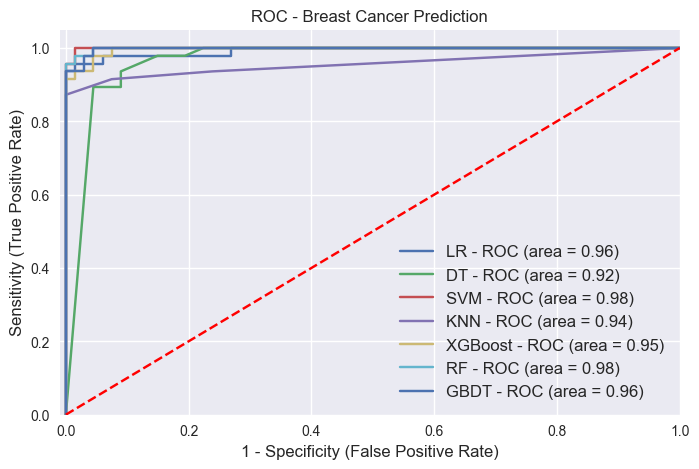

In [518]:
from sklearn import metrics
plt.figure(figsize=(8,5))
models = [
{
    'label': 'LR',
    'model': log_reg,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]
for m in models:
    model = m['model'] 
    if m['label'] == 'KNN':
        X_tr_model, X_te_model = X_train_knn_scaled, X_test_knn_scaled
    elif m['label'] == 'XGBoost':
        X_tr_model, X_te_model = X_train_xgb, X_test_xgb
    elif m['label'] == 'GBDT':
        X_tr_model, X_te_model = X_train_gbc, X_test_gbc
    else:
        X_tr_model, X_te_model = X_train_enc, X_test_enc

    model.fit(X_tr_model, y_train)
    X_test = X_te_model
    y_pred=model.predict(X_test) 
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = metrics.roc_auc_score(y_test,model.predict(X_test))
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1],'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Breast Cancer Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.savefig("roc_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

[96.49, 94.74000000000001, 98.25, 94.74000000000001, 94.74000000000001, 98.25, 96.49]
[96.06, 90.31, 97.87, 93.62, 94.57, 98.19, 97.44]


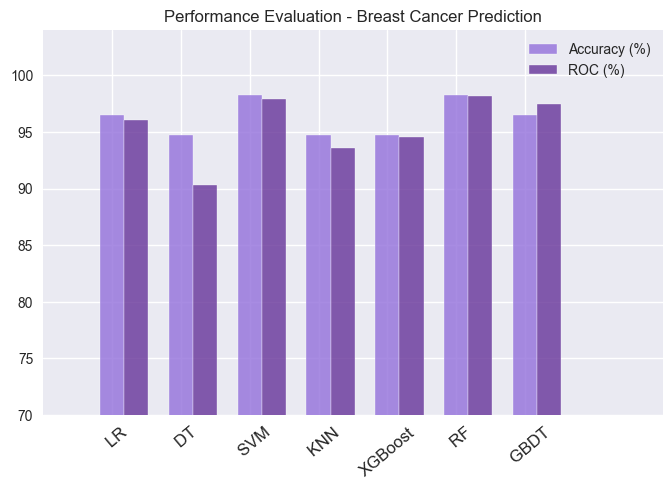

In [ ]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
models = [
{
    'label': 'LR',
    'model': log_reg,
},
{
    'label': 'DT',
    'model': dtc,
},
{
    'label': 'SVM',
    'model': svc,
},
{
    'label': 'KNN',
    'model': knn,
},
{
    'label': 'XGBoost',
    'model': xgb,
},
{
    'label': 'RF',
    'model': rand_clf,
},
{
    'label': 'GBDT',
    'model': gbc,
}
]

means_roc = []
means_accuracy = [100*round(log_reg_acc,4), 100*round(dtc_acc,4), 100*round(svc_acc,4), 100*round(knn_acc,4), 100*round(xgb_acc,4), 
                  100*round(rand_clf_acc,4), 100*round(gbc_acc,4)]

for m in models:
    model = m['model'] 
    if m['label'] == 'KNN':
        X_tr_model, X_test = X_train_knn_scaled, X_test_knn_scaled
    elif m['label'] == 'XGBoost':
        X_tr_model, X_test = X_train_xgb, X_test_xgb
    elif m['label'] == 'GBDT':
        X_tr_model, X_test = X_train_gbc, X_test_gbc
    else:
        X_tr_model, X_test = X_train_enc, X_test_enc

    model.fit(X_tr_model, y_train) 
    y_pred=model.predict(X_test) 
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = metrics.roc_auc_score(y_test,model.predict(X_test))
    auc = 100*round(auc,4)
    means_roc.append(auc)

print(means_accuracy)
print(means_roc)

n_groups = 7
means_accuracy = tuple(means_accuracy)
means_roc = tuple(means_roc)

fig, ax = plt.subplots(figsize=(8,5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, means_accuracy, bar_width,
alpha=opacity,
color='mediumpurple',
label='Accuracy (%)')

rects2 = plt.bar(index + bar_width, means_roc, bar_width,
alpha=opacity,
color='rebeccapurple',
label='ROC (%)')

plt.xlim([-1, 8])
plt.ylim([70, 104])

plt.title('Performance Evaluation - Breast Cancer Prediction', fontsize=12)
plt.xticks(index, ('   LR', '   DT', '   SVM', '   KNN', 'XGBoost' , '   RF', '   GBDT'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.savefig("PE_breast_cancer.jpeg", format='jpeg', dpi=400, bbox_inches='tight')
plt.show()

## PARTIE 8: APPLICATION WEB INTERACTIVE

1. LANCEMENT DIRECT DE STREAMLIT

In [ ]:
import subprocess
import time
import webbrowser
from IPython.display import display, HTML

print("🏥 Lancement de l'Application Médicale...")
print("🔄 Initialisation du système de diagnostic...")
print("⏳ Patientez 5 secondes...")

process = subprocess.Popen([
    "streamlit", "run", "app.py", 
    "--server.port", "8501",
    "--server.headless", "true"
])

time.sleep(5)

display(HTML("""
<div style="background: linear-gradient(135deg, #1a73e8 0%, #8e44ad 100%); 
            padding: 30px; border-radius: 20px; text-align: center; color: white; 
            box-shadow: 0 8px 25px rgba(0,0,0,0.2); margin: 20px 0; border: 3px solid white;">
    <h2 style="margin: 0 0 15px 0; font-size: 2.2rem;">🎗️ APPLICATION MÉDICALE PRÊTE</h2>
    <p style="font-size: 1.2rem; margin: 10px 0;">Système Expert de Diagnostic du <strong>CANCER DU SEIN</strong></p>
    <a href="http://localhost:8501" target="_blank" style="
        display: inline-block; 
        background: white; 
        color: #1a73e8; 
        padding: 18px 40px; 
        text-decoration: none; 
        border-radius: 10px; 
        font-weight: bold;
        font-size: 1.1rem;
        margin: 20px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.3);
        transition: transform 0.3s;">
        🏥 ACCÉDER AU DIAGNOSTIC IA
    </a>
    <p style="margin: 15px 0 0 0; font-size: 1.1rem;"><strong>URL : http://localhost:8501</strong></p>
</div>
"""))

print("✅ Application médicale démarrée avec succès!")
print("🔬 Fonctionnalités disponibles:")
print("   - Diagnostic IA en temps réel")
print("   - Analytics patients avancés") 
print("   - Comparaison d'algorithmes médicaux")
print("   - Interface professionnelle de santé")
print("🌐 Ouvrez votre navigateur sur : http://localhost:8501")

🏥 Lancement de l'Application Médicale...
🔄 Initialisation du système de diagnostic...
⏳ Patientez 5 secondes...


✅ Application médicale démarrée avec succès!
🔬 Fonctionnalités disponibles:
   - Diagnostic IA en temps réel
   - Analytics patients avancés
   - Comparaison d'algorithmes médicaux
   - Interface professionnelle de santé
🌐 Ouvrez votre navigateur sur : http://localhost:8501
